# CA Affordable Housing Tax Credit Intelligence Platform
### Data Cleaning and Exploratory Data Analysis 
#### Primary Source: CTCAC Projects Database

### 1. Import Data

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
import os

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 60)
pd.set_option('display.max_colwidth',40)
pd.set_option('display.float_format', '{:,.0f}'.format)
print('Libraries loaded.')

Libraries loaded.


### 2. Load CTCAC Data 

In [2]:
# Load data
raw_path = 'ctcac_projects.xlsx'
sheet = 'California Mapped Projects'

df_raw = pd.read_excel(raw_path, sheet_name=sheet)
df_raw.shape
#print shape and separate thousands by comma, 6,103
print(f'Shape:{df_raw.shape[0]:,} rows x {df_raw.shape[1]} columns')
print(f'\nColumn names:')
for i, c in enumerate(df_raw.columns):
    print(f'[{i:02d}] {c}')

Shape:6,103 rows x 61 columns

Column names:
[00] Application Number
[01] Type of tax credit funding
[02] Construction Type
[03] Developer
[04] Housing Type
[05] Project Name
[06] Project Address
[07] Project City
[08] Project Zip Code
[09] Project Phone Number
[10] Project County
[11] California Assembly District
[12] California Senate District
[13] Federal Congressional District
[14] Census Tract
[15] Assessor's Parcel Number (APN)
[16] Application Stage
[17] Placed in Service (PIS) Date 
[18] Last Building PIS Date
[19] Total Units
[20] Low Income Units
[21] Number of SRO/Studio Units
[22] Number of 1 Bedroom Units
[23] Number of 2 Bedroom Units
[24] Number of 3 Bedroom Units
[25] Number of 4 Bedroom Units
[26] Number of 5 Bedroom Units
[27] Number of 6 Bedroom Units
[28] Units at or below 20% AMI
[29] Units at or below 30% AMI
[30] Units at 35% AMI
[31] Units at 40% AMI
[32] Units at 45% AMI
[33] Units at 50% AMI
[34] Units at 55% AMI
[35] Units at 60% AMI
[36] Units at 70% AMI
[37

In [3]:
# check data type
df_raw.info(verbose=True, show_counts=True)

<class 'pandas.DataFrame'>
RangeIndex: 6103 entries, 0 to 6102
Data columns (total 61 columns):
 #   Column                          Non-Null Count  Dtype         
---  ------                          --------------  -----         
 0   Application Number              6103 non-null   str           
 1   Type of tax credit funding      6103 non-null   object        
 2   Construction Type               5616 non-null   str           
 3   Developer                       5316 non-null   str           
 4   Housing Type                    5622 non-null   str           
 5   Project Name                    6086 non-null   str           
 6   Project Address                 6103 non-null   str           
 7   Project City                    6103 non-null   str           
 8   Project Zip Code                6103 non-null   object        
 9   Project Phone Number            4388 non-null   object        
 10  Project County                  6103 non-null   str           
 11  California Asse

In [4]:
# Preview first few rows:
df_raw.head()

,Application Number,Type of tax credit funding,Construction Type,Developer,Housing Type,Project Name,Project Address,Project City,Project Zip Code,Project Phone Number,Project County,California Assembly District,California Senate District,Federal Congressional District,Census Tract,Assessor's Parcel Number (APN),Application Stage,Placed in Service (PIS) Date,Last Building PIS Date,Total Units,Low Income Units,Number of SRO/Studio Units,Number of 1 Bedroom Units,Number of 2 Bedroom Units,Number of 3 Bedroom Units,Number of 4 Bedroom Units,Number of 5 Bedroom Units,Number of 6 Bedroom Units,Units at or below 20% AMI,Units at or below 30% AMI,...,Units at 40% AMI,Units at 45% AMI,Units at 50% AMI,Units at 55% AMI,Units at 60% AMI,Units at 70% AMI,Units at 80% AMI,Owner or Applicant Name,Owner/Applicant Contact,Owner/Applicant Address,Owner/Applicant City,Owner/Applicant State,Owner/Applicant Zip,Owner/Applicant Phone,Owner/Applicant Fax,General Partner (1),General Partner (2),General Partner (3),General Partner (4),General Partner (5),Management Company,Management Company Contact,Management Company Address,Management Company City,Management Company State,Management Company Zip,Management Company Phone,Management Company Fax,Annual Federal Award,Total State Award
0,CA-1989-279,0,New Construction,Opportunity Housing,Large Family,Tres Palmas Village 90-001,"1631 Malan Street, Brawley, CA 92227",Brawley,92227,7609227242,Imperial,36,18,25,NaN,NaN,Extended,1990-01-01 00:00:00,1990-01-01,55,55,0,0,0,0,0,0,0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Quality Housing Development Corporation,Mark Eulberg,PO Box 395,Auburn,CA,95604-0395,5303056868,5308232585,Quality Housing Development Corporation,NaN,NaN,NaN,NaN,"The CBM Group, Inc.",John Kammerer,1010 Racquet Club Drive Suite 108,Auburn,CA,95603,5308232477,5308232585,"98,141",NaN
1,CA-1990-011,0,New Construction,"CKMP, Inc",Large Family,Villa Los Robles,"473 North Los Robles Avenue, Pasaden...",Pasadena,91101,3232311107,Los Angeles,41,25,27,4619.01,NaN,Extended,1992-01-23 00:00:00,1992-01-23,8,8,0,0,0,0,0,0,0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Villa Los Robles Partners LP,Perla Easton,"5670 Wilshire Blvd., Suite 1780",Los Angeles,CA,90036,3232855664,3239044101,Robles & Villa Inc.,NaN,NaN,NaN,NaN,HDSI Management Inc.,Carlos Baez,3460 Broadway,Los Angeles,CA,90007,3232311107,3232320094,"73,349","357,576"
2,CA-1990-012,0,New Construction,New Economics for Women,Large Family,Casa Loma Apartments,"379 South Loma Drive, Los Angeles, C...",Los Angeles,90017,2134849805,Los Angeles,53,24,34,2091.04,NaN,Extended,1993-05-24 00:00:00,1993-05-24,110,110,4,32,42,32,0,0,0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,379 Loma Limited Partnership,Leticia Andueza,303 South Loma Drive,Los Angeles,CA,90017,2134832060,2134837848,New Economics for Women,NaN,NaN,NaN,NaN,"New Capital, LLC",Esmeralda Rivera,303 South Loma Drive,Los Angeles,CA,90017,2134841008,2134837848,"1,516,495",NaN
3,CA-1990-014,0,New Construction,"S.P.G. Housing, Inc.",Large Family,San Pedro Gardens,"16716 San Luis Drive, Morgan Hill, C...",Morgan Hill,95037,4086269262,Santa Clara,30,17,19,5123.10,NaN,Extended,1992-08-14 00:00:00,1992-08-17,20,17,0,0,0,0,0,0,0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"San Pedro Gardens Associates, Ltd.",Sally Adams,505 West Julian Street,San Jose,CA,95110,4089933091,4089753845,"S.P.G. Housing, Inc.",NaN,NaN,NaN,NaN,John Stewart Company,Stephany Reyes,"104 Whispering Pines Drive, Suite 200",Scotts Valley,CA,95066,8314385725,8314385737,"277,540",NaN
4,CA-1990-018,0,New Construction,"Housing Partners, Inc.",Seniors,Yucaipa Terrace,"12435 Sixth Street, Yucaipa, CA 92399",Yucaipa,92399,9098905397,San Bernardino,42,23,8,87.04,NaN,Extended,1991-10-24 00:00:00,1991-10-24,51,51,0,0,0,0,0,0,0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Housing Authority of the County of S...,Maria Razo,715 E. Brier Drive,San Bernardino,CA,92408,9093326305,9093326305,Housing Authority of the County of S...,NaN,NaN,NaN,NaN,Housing Authority of 

In [5]:
df_raw.describe()

,California Assembly District,California Senate District,Federal Congressional District,Last Building PIS Date,Total Units,Low Income Units,Number of SRO/Studio Units,Number of 1 Bedroom Units,Number of 2 Bedroom Units,Number of 3 Bedroom Units,Number of 4 Bedroom Units,Number of 5 Bedroom Units,Number of 6 Bedroom Units,Units at or below 20% AMI,Units at or below 30% AMI,Units at 35% AMI,Units at 40% AMI,Units at 45% AMI,Units at 50% AMI,Units at 55% AMI,Units at 60% AMI,Units at 70% AMI,Units at 80% AMI,Annual Federal Award,Total State Award
count,"5,885","5,885","5,881",4759,"5,625","5,625","5,423","5,546","5,586","5,517","5,405","5,342","5,234","1,068","3,154","3,061","3,103","3,089","3,182","3,058","3,142","1,061","1,084","5,574","1,197"
mean,36,19,24,2011-03-20 23:10:40.722841,88,84,12,31,25,16,2,0,0,2,14,1,5,2,25,1,32,10,5,"1,224,622","4,711,814"
min,1,1,1,1990-01-01 00:00:00,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,100,0
25%,17,9,12,2004-11-19 00:00:00,48,46,0,1,1,0,0,0,0,0,0,0,0,0,8,0,0,0,0,"439,359","1,626,747"
50%,32,17,22,2011-12-08 00:00:00,72,69,0,18,16,9,0,0,0,0,7,0,0,0,19,0,16,0,0,"850,326","3,037,732"
75%,54,29,36,2018-04-13 00:00:00,107,102,1,45,34,24,0,0,0,0,20,0,6,0,32,0,42,0,0,"1,591,996","5,700,000"
max,80,89,52,2424-02-15 00:00:00,840,830,431,761,556,271,100,20,6,74,172,75,142,150,557,109,746,217,130,"16,529,220","36,875,099"
std,23,12,15,NaN,65,62,32,40,33,21,7,1,0,8,19,5,11,8,28,5,47,28,14,"1,209,840","5,079,514"


In [6]:
missing = df_raw.isnull().sum()
#calculate missing percentage, missing data df.isnull()== True is 1, False is 0. 
#mean is missing rate.round 2 decimal
missing_pct = (df_raw.isnull().mean()*100).round(2)
missing_report = pd.DataFrame({'missing_count':missing, 'missing_pct': missing_pct})
missing_report = missing_report[missing_report['missing_count'] > 0].sort_values('missing_pct', ascending = False)

print(f'Columns with missing data: {len(missing_report)} of {df_raw.shape[1]}')
missing_report

Columns with missing data: 50 of 61


,missing_count,missing_pct
General Partner (5),6101,100
General Partner (4),6079,100
General Partner (3),5773,95
Units at 70% AMI,5042,83
Units at or below 20% AMI,5035,82
Units at 80% AMI,5019,82
Total State Award,4906,80
General Partner (2),3116,51
Units at 55% AMI,3045,50
Units at 35% AMI,3042,50


---
## 3b. Column Triage — Role Assignment

The raw CTCAC dataset has 61 columns. Before exploring or cleaning, we assign each column
a role to justify what enters the model and what doesn't. This prevents ad-hoc feature
selection and ensures every inclusion/exclusion decision is documented.

**Methodology note:** This triage is domain-driven — roles are assigned based on knowledge
of LIHTC deal structure and what information is available at prediction time. This is the
appropriate starting point for a structured dataset from a government source, where most
columns have clear semantic meaning. Empirical validation (feature importance, correlation
with target) is performed in the modeling notebook to confirm these hypotheses. The few
debatable exclusions are discussed explicitly at the bottom of this section.

**Roles:**
- **Target** — what the model predicts
- **Feature** — input to the model (after cleaning/engineering)
- **ID / Metadata** — used for indexing, joining, or display but not as model input
- **Exclude** — not useful for prediction; reason documented below

### Target
| Column | Reason |
|--------|--------|
| `Annual Federal Award` | The primary prediction target — the single most important number in a LIHTC deal |

### Features (used directly or engineered)
| Column | Role in model |
|--------|---------------|
| `Type of tax credit funding` | 9% vs 4% — determines credit rate and deal structure |
| `Construction Type` | New Construction vs Rehabilitation — affects eligible basis rules |
| `Housing Type` | Senior, Family, SRO, etc. — drives unit mix and AMI targeting patterns |
| `Project County` | Geographic signal; grouped into regions to avoid 58 sparse dummies |
| `Total Units` | Project scale — strongest predictor of credit size |
| `Low Income Units` | Restricted unit count; engineered into `li_units_pct` |
| `Number of SRO/Studio–6 Bedroom Units` (7 cols) | Engineered into bedroom mix percentages |
| `Units at X% AMI` (10 cols) | Engineered into `deep_ami_pct` and `mid_ami_pct` |
| `Placed in Service (PIS) Date` | Parsed to `pis_year` — captures cost escalation over time |

### ID / Metadata (kept for joins, display, or filtering — not model input)
| Column | Purpose |
|--------|---------|
| `Application Number` | Unique project ID |
| `Project Name` | Display label |
| `Project City` | More granular than county; kept for display, not as a feature (too many unique values) |
| `Census Tract` | Used to join Census ACS data in the enrichment notebook |
| `Application Stage` | Used for filtering (only placed-in-service projects), not as a feature |
| `Developer` | Kept for comparables display; too many unique values for a feature (see below) |
| `Last Building PIS Date` | Secondary date; not needed alongside PIS Date |

### Excluded (not useful for prediction)
| Column | Reason |
|--------|--------|
| `Project Address`, `Project Zip Code` | Redundant with County + Census Tract |
| `Project Phone Number` | Contact info, not a project characteristic |
| `CA Assembly/Senate/Congressional District` (3 cols) | Geographic proxy, redundant with county (see below) |
| `Assessor's Parcel Number (APN)` | Property identifier, not a feature |
| `Owner/Applicant` fields (8 cols) | Contact/admin info — name, address, phone, fax |
| `General Partner (1–5)` (5 cols) | Entity names; too sparse (GP3: 5%, GP4: 0.4%) and free-text |
| `Management Company` fields (7 cols) | Post-construction operations info, not relevant to credit allocation |
| `Total State Award` | Co-output with federal award, not an input (see below) |

### Debatable exclusions — why we chose not to include them

The 21 contact/admin columns (owner address, management company phone, fax, etc.) are
unambiguously irrelevant — no feature importance analysis needed. The columns below are
the only genuinely debatable ones. We evaluated whether adding them and running empirical
feature importance would improve the model, and concluded it would not:

**Political districts (3 cols: Assembly, Senate, Congressional)**
These are geographic proxies strongly correlated with county. Each county falls within
specific districts, and county → region is already a feature. Adding districts gives the
model three more ways to encode location, creating multicollinearity without independent
signal. CTCAC allocates credits at the state level, not through congressional earmarks.
With only 4,200 rows, the greater risk is overfitting on geographic noise, not
underfitting from missing a district effect. Hassle: low, but payoff: near zero.

**Total State Award (20% coverage)**
State and federal credits are often awarded in the same allocation round. This makes
Total State Award a co-output of the same decision process, not an input — using it as
a feature would be data leakage. Additionally, 80% of rows are NaN, requiring imputation
that would introduce noise. Hassle: moderate (imputation strategy + leakage analysis).
Payoff: questionable at best, harmful at worst.

**Developer (~1,000+ unique values, 87% coverage)**
Large developers (e.g., Related California, Eden Housing) might systematically receive
different award sizes, but that signal is already captured by the project characteristics
those developers tend to produce (unit count, housing type, region, credit type).
Developer name is a proxy for those features, not an independent cause. Target encoding
on 1,000+ developers with only 4,200 rows would require heavy regularization to avoid
overfitting — most developers appear only 1–3 times. Hassle: high. Payoff: signal is
almost certainly already captured by existing features.

**General principle:** With a dataset of ~4,200 rows, the risk of overfitting from adding
marginal features outweighs the risk of underfitting from excluding them. Effort is better
spent on validating the features we do have (checking for leakage in derived features,
tuning the model) than on testing columns with low expected signal.

### 4. Explore Key Categorical Columns 
##### These are our model features, need to understadn their distributions and spot any dirty values.

In [7]:
# Check application stage to decide if a project is completed and usable for training
# Should not use project data that hasnt completed construction/ still in construction 
print('== Application Stage ==')
print(df_raw['Application Stage'].value_counts(dropna=False))

== Application Stage ==
Application Stage
Placed in Service          2755
EXTENDED                   2047
Preliminary Reservation     772
Extended                    474
Re-Application               21
Placed In Service            17
In Receivership              15
Compliance Period Ended       1
Final Reservation             1
Name: count, dtype: int64


In [8]:
# Check credit type (9% vs. 4%)
# One of the most important cost predictors in LIHTC.
# 9% credits are highly competitive and fund projects that are typically more expensive per unit. 
# 4% credits pair with tax-exempt bonds and tend to be cheaper/larger. 
print('==Type of Tax Credit Funding==')
print(df_raw['Type of tax credit funding'].value_counts(dropna=False))

==Type of Tax Credit Funding==
Type of tax credit funding
0           3491
0           2483
 9% ARRA      66
 4% ARRA      60
 9%            3
Name: count, dtype: int64


In [9]:
# --- Construction Type ---
# rehab and new construction has different cost structures
# Rehab projects can only claim credits on certain cost categories
# and affect eligible basis differently under LIHTC rules.
print('=== Construction Type ===')
print(df_raw['Construction Type'].value_counts(dropna=False))

=== Construction Type ===
Construction Type
New Construction                                 3769
Acquisition/Rehabilitation                        847
Acquisition/Rehab                                 635
NaN                                               487
Rehabilitation                                    302
Adaptive Reuse                                     27
Aquisition/Rehabilitation                          15
Acq and Rehabilitation                              9
Acquistion/Rehabilitation                           3
Acquisition/Rehabiliation                           2
Resyndication                                       2
NC/AR                                               1
New Construction/Acq Rehab                          1
Aquisition/Rehab                                    1
New Construction & Acquisition/Rehabilitation       1
Acquisition & Rehabilitation                        1
Name: count, dtype: int64


In [10]:
# --- Housing Type ---
# different housing types affect credit award amount
print('=== Housing Type ===')
print(df_raw['Housing Type'].value_counts(dropna=False))

# Note: messy casing — 'Seniors' vs 'Senior', 'Large Family' vs 'Large family'
# We will normalize these

=== Housing Type ===
Housing Type
Large Family                                          2585
Seniors                                               1060
Non-Targeted                                           967
Special Needs                                          597
NaN                                                    481
At-Risk                                                239
Single Room                                            145
SRO                                                      9
Special Needs/Large Family                               5
Non-targeted                                             3
non-targeted                                             2
at-risk                                                  2
Large Family                                             2
Large family                                             1
SRO/At-Risk                                              1
 Special Needs                                           1
Large Family/At-Risk (

In [11]:
# --- County distribution (top 20) ---
#Location affects the Applicable Fraction indirectly (via income limits, area median income tiers) 
# and signals project scale patterns. 
#Also relevant for any geographic fixed effects in the model.
print('=== Top 20 Counties ===')
print(df_raw['Project County'].value_counts().head(20))

=== Top 20 Counties ===
Project County
Los Angeles        1530
San Diego           474
Santa Clara         342
Alameda             318
San Francisco       272
Orange              264
Sacramento          255
Riverside           234
Fresno              194
Contra Costa        161
Kern                160
Sonoma              142
San Bernardino      137
Ventura             133
Tulare              105
Monterey            104
Santa Barbara        99
San Mateo            90
Imperial             83
San Luis Obispo      82
Name: count, dtype: int64


### 5. Explore the Target Variable: Annual Federal Award

##### This is what we're predicting. Understanding its distribution is critical before choosing a model.

In [12]:
# target variable
award = df_raw['Annual Federal Award']
print(f'Total rows:          {len(award):,}')
print(f'Non-null:            {award.notna().sum():,}  ({award.notna().mean()*100:.2f}%)')
print(f'> 0:                 {(award > 0).sum():,}')
print(f'= 0 or null:         {(award.isna() | (award == 0)).sum():,}')
print()
print('Distribution of non-zero values:')
print(award[award > 0].describe())
#print(award[award > 0].describe().apply('{:,.0f}'.format))

Total rows:          6,103
Non-null:            5,574  (91.33%)
> 0:                 5,574
= 0 or null:         529

Distribution of non-zero values:
count        5,574
mean     1,224,622
std      1,209,840
min            100
25%        439,359
50%        850,326
75%      1,591,996
max     16,529,220
Name: Annual Federal Award, dtype: float64


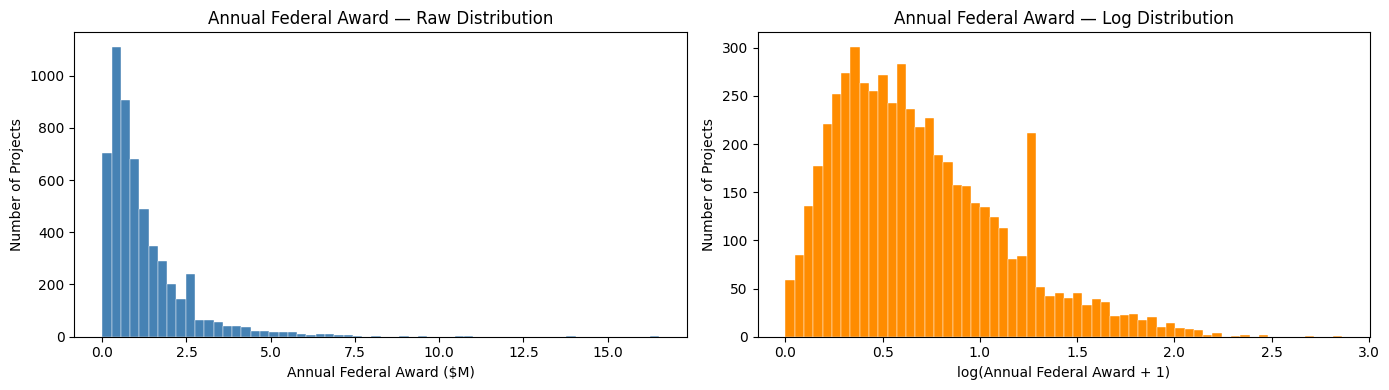


Note: Log distribution is closer to normal — consider log-transforming the target for modeling.


In [13]:
#compare 2 plots on the same row side by side
fig, axes = plt.subplots(1, 2, figsize = (14,4))

vals = award[award >0].dropna() / 1_000_000 # scale to $million

# Raw distribution, left gra
axes[0].hist(vals, bins=60, color='steelblue', edgecolor='white', linewidth=0.3)
axes[0].set_title('Annual Federal Award — Raw Distribution', fontsize=12)
axes[0].set_xlabel('Annual Federal Award ($M)')
axes[0].set_ylabel('Number of Projects')

# Log distribution (better for skewed financial data)
# Log Transformation
axes[1].hist(np.log1p(vals), bins=60, color='darkorange', edgecolor='white', linewidth=0.3)
axes[1].set_title('Annual Federal Award — Log Distribution', fontsize=12)
axes[1].set_xlabel('log(Annual Federal Award + 1)')
axes[1].set_ylabel('Number of Projects')

plt.tight_layout()
plt.show()

print('\nNote: Log distribution is closer to normal — consider log-transforming the target for modeling.')

### 6. Explore Time Dimension
##### We need the Placed-in-Service year as a model feature AND for the train/test split.
##### Will train on 2000-2021, test on 2022-2025

In [14]:
# Parse place in service(PIS) date and extract year
# errors='coerce' will place error date (ex."9999-99-99"） to NaT（Not a Time)
df_raw['pis_date'] = pd.to_datetime(df_raw['Placed in Service (PIS) Date '], errors='coerce')
df_raw['pis_year'] = df_raw['pis_date'].dt.year

print('PIS year range:', df_raw['pis_year'].min(), '–', df_raw['pis_year'].max())
print(f'Missing PIS date: {df_raw["pis_year"].isna().sum():,} rows')
print()

# Flag the impossible years (data entry errors), data downloaded in 2/2026
bad_years = df_raw[df_raw['pis_year'] > 2026]
print(f'PIS year > 2026 (likely errors or future prelim reservations): {len(bad_years):,}')
print(df_raw['pis_year'].value_counts().sort_index())
#print(df_raw['pis_year'].value_counts().sort_index().tail(15))


PIS year range: 1990.0 – 2500.0
Missing PIS date: 46 rows

PIS year > 2026 (likely errors or future prelim reservations): 312
pis_year
1,990      2
1,991      7
1,992     40
1,993     46
1,994     69
1,995     76
1,996     77
1,997     80
1,998     95
1,999    161
2,000    149
2,001    115
2,002    109
2,003    128
2,004    141
2,005    186
2,006    200
2,007    211
2,008    224
2,009    157
2,010    121
2,011    204
2,012    192
2,013    217
2,014    252
2,015    160
2,016    220
2,017    269
2,018    242
2,019    189
2,020    177
2,021    184
2,022    180
2,023    267
2,024    275
2,025    165
2,026    158
2,027    215
2,028     91
2,029      2
2,030      3
2,500      1
Name: count, dtype: int64


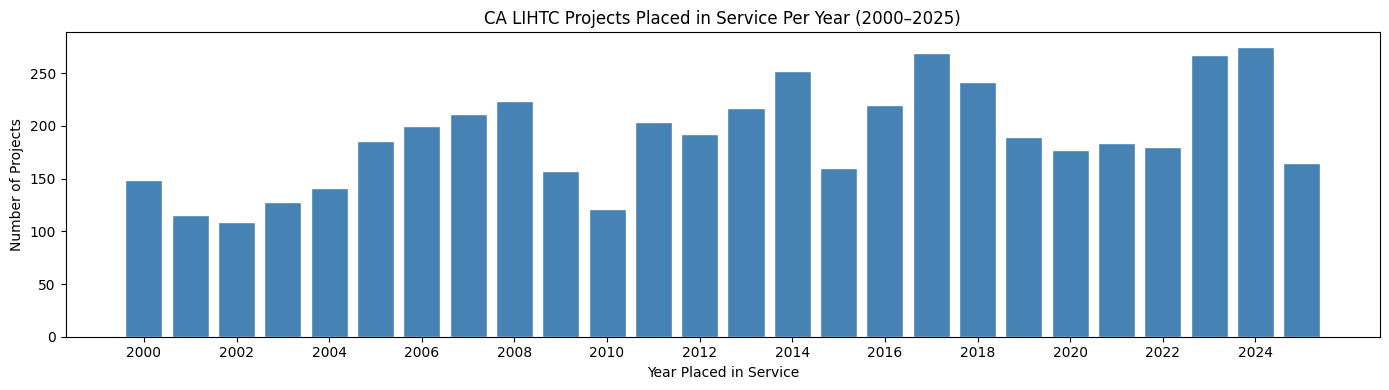

In [15]:
# Projects placed in service per year (2000 onward)
year_counts = df_raw[df_raw['pis_year'].between(2000, 2025)]['pis_year'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(14, 4))
ax.bar(year_counts.index, year_counts.values, color='steelblue', edgecolor='white')
ax.set_title('CA LIHTC Projects Placed in Service Per Year (2000–2025)', fontsize=12)
ax.set_xlabel('Year Placed in Service')
ax.set_ylabel('Number of Projects')
ax.set_xticks(range(2000, 2026, 2))
plt.tight_layout()
plt.show()

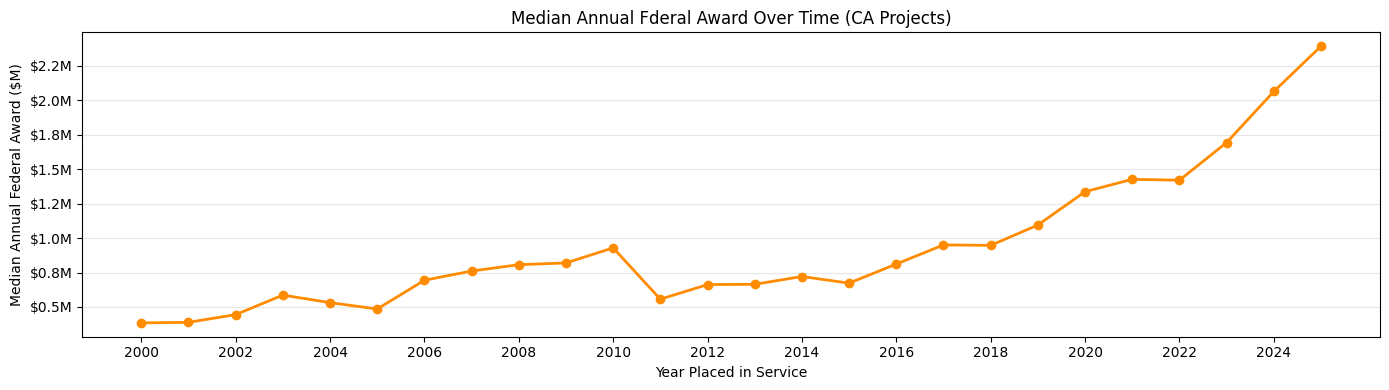


This is the time trend our model must learn.
Including pis_year and FRED PPI as features captures this escalation.


In [16]:
# Annual Federal Award trend over time (2000 to 2025)
# Look at median federal award per year
trend = (
    df_raw[df_raw['pis_year'].between(2000,2025) & (df_raw['Annual Federal Award'] > 0)]
    .groupby('pis_year')['Annual Federal Award']
    .median()
)
#trend, in Million
fig, ax = plt.subplots(figsize = (14,4))
ax.plot(trend.index, trend.values/1_000_000, marker='o', color='darkorange', linewidth=2)
ax.set_title('Median Annual Fderal Award Over Time (CA Projects)', fontsize=12)
ax.set_xlabel('Year Placed in Service')
ax.set_ylabel('Median Annual Federal Award ($M)')
# set y axis format, add $, set 1 digit(%.1f), add per M(million)
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('$%.1fM'))
# from 2000 - 2025
ax.set_xticks(range(2000, 2026, 2))
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()
print('\nThis is the time trend our model must learn.')
print('Including pis_year and FRED PPI as features captures this escalation.')

### 7. Explore Unit Mix & AMI Targeting

In [17]:
print('=== Total Units Distribution ===')
print(df_raw['Total Units'].describe())
print()

# Print Outliers - very small or very large project
print('Projects with < 5 units:', (df_raw['Total Units'] < 5).sum())
print('Projects with > 400 units:', (df_raw['Total Units'] > 400).sum())

=== Total Units Distribution ===
count   5,625
mean       88
std        65
min         1
25%        48
50%        72
75%       107
max       840
Name: Total Units, dtype: float64

Projects with < 5 units: 4
Projects with > 400 units: 18


In [18]:
# AMI targeting columns — check coverage
ami_cols = [
    'Units at or below 20% AMI', 'Units at or below 30% AMI',
    'Units at 35% AMI', 'Units at 40% AMI', 'Units at 45% AMI',
    'Units at 50% AMI', 'Units at 55% AMI', 'Units at 60% AMI',
    'Units at 70% AMI', 'Units at 80% AMI'
]

print('AMI targeting column coverage (% non-null):')
for col in ami_cols:
    # find units that are not NaN, return True(1), or False(0), calculate mean *100 to get percentage
    pct = df_raw[col].notna().mean() * 100
    bar = '*' * int(pct)
    #bar = '*' * int(pct/5)
    # column name and percentage has35 spaces, 
    print(f'  {col:<35} {pct:5.1f}%  {bar}')

AMI targeting column coverage (% non-null):
  Units at or below 20% AMI            17.5%  *****************
  Units at or below 30% AMI            51.7%  ***************************************************
  Units at 35% AMI                     50.2%  **************************************************
  Units at 40% AMI                     50.8%  **************************************************
  Units at 45% AMI                     50.6%  **************************************************
  Units at 50% AMI                     52.1%  ****************************************************
  Units at 55% AMI                     50.1%  **************************************************
  Units at 60% AMI                     51.5%  ***************************************************
  Units at 70% AMI                     17.4%  *****************
  Units at 80% AMI                     17.8%  *****************


### 8. Clean the Data
##### Based on the exploration above, here is every cleaning step and why we're doing it.

In [19]:
df = df_raw.copy()
# Step 1. Parse dates and extract year

# coerce error so invalid/ missing dates will be NaT(Not a Time) and wont cause error
df['pis_date'] = pd.to_datetime(df['Placed in Service (PIS) Date '], errors = 'coerce')
df['pis_year'] = df['pis_date'].dt.year
# Fix data entry errors: pis_year > 2026 is impossible (data downloaded Feb 2026)
# Legitimate future projects (2026-2030) are kept; only obvious errors like 2500 are fixed
n_bad_year = (df['pis_year'] > 2030).sum()
df.loc[df['pis_year'] > 2030, 'pis_year'] = np.nan
print(f'Step 1 done: PIS year parsed. Fixed {n_bad_year} rows with impossible pis_year → NaN')
#df['pis_year']

Step 1 done: PIS year parsed. Fixed 1 rows with impossible pis_year → NaN


#### ── Step 2: Drop unusable rows — before any categorical mapping ───────────────
All three sub-steps below run BEFORE Steps 3–5 (categorical mapping) so that fillna/map operations only touch rows with real, usable data.

Note: the placed-in-service stage filter and year window (2000–2025) that were previously here have been moved to 03_feature_engineering.ipynb. This cleaning notebook produces a general-purpose clean artifact (ctcac_clean.parquet) that is not scoped to any particular training window. Scope filtering is a modeling decision — it belongs in the training pipeline alongside the train/test split, not in data cleaning. This allows the clean artifact to be reused if the training window changes or if a different model scope is needed.

In [20]:
# Step 2a: Drop near empty rows
# Cannot assume totoal units
print('Step 2a: Investigate rows with NaN Total Units')
# df for null total units
null_tu = df[df['Total Units'].isna()]
#null_tu
n_tu = len(null_tu)
print(f'Rows with NaN Total Units: {n_tu}')

null_cons_type = null_tu['Construction Type'].isna().sum()
null_house_type = null_tu['Housing Type'].isna().sum()
null_fed_award = null_tu['Annual Federal Award'].isna().sum()
print(f'Also missing Construction Type: {null_cons_type}, Percentage: {null_cons_type/n_tu *100:.2f}%')
print(f'Also missing Housing Type: {null_house_type}, Percentage: {null_house_type/n_tu *100:.2f}%')
print(f'Also missing Total Fderal Award: {null_fed_award}, Percentage: {null_fed_award/n_tu *100:.2f}%')
print(f'Has valid Annual Federal Award > 0: {null_fed_award}')
print()

# Total Units is the correct filter criterion here, not Construction Type:
#   - Every row with NaN Total Units also has NaN Construction Type (perfect overlap)
#   - Without Total Units, no derived features can be computed (bedroom percentages,
#     li_units_pct, credit_per_unit, implied_basis_per_unit) — the row is unusable
#     regardless of any other field's value
#   - Imputing Total Units from no signal would fabricate a core model feature
# DROP NAN total units
before = len(df)
print(f'Before Dropping: {before}')
df = df[df['Total Units'].notna()].copy()
after = len(df)
print(f'After Dropping: {after}')
print(f'Step 2a done: dropped {before - after:,} near-empty rows (NaN Total Units).')
print(f'  Rows remaining: {after:,}')

Step 2a: Investigate rows with NaN Total Units
Rows with NaN Total Units: 478
Also missing Construction Type: 478, Percentage: 100.00%
Also missing Housing Type: 477, Percentage: 99.79%
Also missing Total Fderal Award: 477, Percentage: 99.79%
Has valid Annual Federal Award > 0: 477

Before Dropping: 6103
After Dropping: 5625
Step 2a done: dropped 478 near-empty rows (NaN Total Units).
  Rows remaining: 5,625


#### ── Step 2b: Drop ARRA rows ────────────────────────────────────────────────────
ARRA (American Recovery and Reinvestment Act, 2009) was a one-time stimulus program where the Section 1602 exchange replaced tax credits with direct cash grants for many projects. This makes ARRA projects structurally incomparable to standard LIHTC deals in two ways:

(1) Award data is unreliable: investigation shows 35 of 68 ARRA survivors have Annual Federal Award values of $100 or  $10,000 — placeholder entries, not real credit allocations. A comparable 9% project of the same size in the same years had a median award of ~$1,046,000. These values would corrupt the model's understanding of what a 9% or 4% award looks like.

(2) Deal structure differs: ARRA projects that did retain tax credits received them alongside a direct cash grant that effectively subsidised a below-market credit. The credit amount is not comparable to a standard deal underwritten purely on tax credit equity.

Removing ARRA rows here — before credit_type mapping in Step 3 — ensures '9% ARRA' / '4% ARRA' values never reach the credit_map dict.

In [21]:
# Step 2b. Check credit type

# check column unique values 
print(df['Type of tax credit funding'].apply(type).value_counts())
print('--Unique values: Type of tax credit funding--')
print(df['Type of tax credit funding'].unique())

Type of tax credit funding
<class 'float'>    5509
<class 'str'>       116
Name: count, dtype: int64
--Unique values: Type of tax credit funding--
[0.09 0.04 '9% ARRA' '4% ARRA' '9%']


In [22]:
print('Step 2b: Dropping ARRA Rows')
# Find rows where 'Type of tax credit funding' contains 'ARRA' (case-insensitive), treating NaN as False
# arra_mask is a boolean Series where True indicates rows to drop (those containing 'ARRA')
# It's not a dataframe, but a Series of True/False values corresponding to each row in df
# Can use df[~arra_mask] to get rows that do not contain 'ARRA' later, which doesnt work if arra_mask is a dataframe
arra_mask = df['Type of tax credit funding'].astype(str).str.contains('ARRA', case=False, na=False)
#arra_mask
print(f'ARRA rows to be dropped: {arra_mask.sum()}')
#print(f' 9% ARRA rows: {(df[arra_mask]['Type of tax credit funding'].str.contains("9%", case=False).sum())}')
print(f' 9% ARRA rows: {(df['Type of tax credit funding'] == "9% ARRA").sum()}')
print(f' 4% ARRA rows: {(df['Type of tax credit funding'] == "4% ARRA").sum()}')

# Only keep non-ARRA rows and make a copy to avoid SettingWithCopyWarning
# df[~arra_mask] will return rows where arra_mask is False (not containing ARRA)
df = df[~arra_mask].copy()
arra_after = len(df)
print(f'Step 2 done: dropped {arra_mask.sum() :,} ARRA rows. Remaining rows: {arra_after:,}')

Step 2b: Dropping ARRA Rows
ARRA rows to be dropped: 114
 9% ARRA rows: 58
 4% ARRA rows: 56
Step 2 done: dropped 114 ARRA rows. Remaining rows: 5,511


### ── Step 2c: Drop rows with NaN Construction Type ─────────────────────────────
After Step 2a removed near-empty rows, a small number of rows remain with valid data in all other fields but no Construction Type recorded by CTCAC. These cannot be imputed: no other column in the dataset (credit type, housing type, unit count, AMI targeting) distinguishes New Construction from Rehabilitation. Unlike housing type, which has a legitimate 'Non-Targeted default for unmapped rows, construction type has no safe default — the two categories follow different eligible basis rules under LIHTC and would affect the model's learned relationship between project characteristics and award size.

In [23]:
print('\n── Step 2c: Dropping remaining NaN Construction Type rows ──')
# Data frame with NA construction type
null_ct = df[df['Construction Type'].isna()]
#null_ct
print(f'Rows with NaN Construction Type: {len(null_ct):,}')
before = len(df)
#before
df = df[df['Construction Type'].notna()].copy()
after = len(df)
print(f'Step 2c done: dropped {before - after:,} rows with NaN/ Unknown Construction Type.')
print(f'Remaining rows: {after:,}')




── Step 2c: Dropping remaining NaN Construction Type rows ──
Rows with NaN Construction Type: 9
Step 2c done: dropped 9 rows with NaN/ Unknown Construction Type.
Remaining rows: 5,502


In [24]:
# Step 3. Recode credit type

# Stored as float 0.09 / 0.04 in raw data. Convert to clean string labels.
# ARRA rows were removed in Step 2b so '9% ARRA' / '4% ARRA' no longer appear.
# The '9%' string variant (3 rows) covers edge cases in the raw data.
# fillna('4%') is a defensive default for future re-downloads — there are zero
# actual NaN credit type rows after Step 2b.

credit_map = {0.09: '9%', 0.04: '4%', '9%': '9%'}

# Map and Fill missing values to default 4% (like rehab, more conservative
df['credit_type']= df['Type of tax credit funding'].map(credit_map).fillna('4%')
print('Step 3 done: credit_type cleaned.')

unmapped_ct = df['credit_type'].isna().sum()
if unmapped_ct:
    print(f'  WARNING: {unmapped_ct} unmapped credit_type values — check raw data')
# print distribution of credit type after mapping in dictionary format
print(' Distribution:', df['credit_type'].value_counts().to_dict())

Step 3 done: credit_type cleaned.
 Distribution: {'4%': 3119, '9%': 2383}


In [25]:
# Step 4: Normalize housing type (fix messy casing)
# check Housing Type unique valus:
print(df['Housing Type'].apply(type).value_counts())
print('--Unique values: Housing Type--')
housing_type = df['Housing Type'].dropna().unique()
print(np.sort(housing_type))


Housing Type
<class 'str'>      5499
<class 'float'>       3
Name: count, dtype: int64
--Unique values: Housing Type--
[' Special Needs' 'At-Risk' 'Large Family' 'Large Family '
 'Large Family and Senior'
 'Large Family/At-Risk (Waiver Required Sect. 10325(' 'Large family'
 'Non-Targeted' 'Non-targeted' 'SRO' 'SRO/At-Risk' 'Seniors' 'Seniors '
 'Single Room' 'Special Needs' 'Special Needs/Large Family' 'non-targeted']


In [26]:
# Step 4: Normalize housing type (fix messy casing) and group into categories
housing_map = {
    'At-Risk': 'At-Risk',
    'at-risk': 'At-Risk',
    'Large Family': 'Large Family',
    'Large Family ': 'Large Family',
    'Large Family and Senior': 'Large Family',
    'Large Family/At-Risk (Waiver Required Sect. 10325(': 'Large Family',
    'Large family': 'Large Family',
    'Non-Targeted': 'Non-Targeted',
    'Non-targeted': 'Non-Targeted',
    'non-targeted': 'Non-Targeted',
    'SRO': 'SRO',
    'SRO/At-Risk': 'At-Risk',
    'Seniors': 'Senior',
    'Seniors ': 'Senior',
    'Single Room': 'SRO',
    ' Special Needs':'Special Needs',
    'Special Needs':'Special Needs',
    'Special Needs/Large Family': 'Special Needs'}

print(f' NaN housing types before mapping: {df["Housing Type"].isna().sum()}')
# After Step 2a removed near-empty rows, only ~3 NaN housing types remain.
# These are real records with valid data in all other fields.
# 'Non-Targeted' is a legitimate CTCAC category meaning the project doesn't
# fit a defined housing type — appropriate for these few remaining rows.

df['housing_type'] = df['Housing Type'].map(housing_map).fillna('Non-Targeted')

print('Step 4 done: housing_type mapped and normalized.')
print(f'  NaN filled with Non-Targeted: {df["Housing Type"].isna().sum()}')
print(f'Distribution: {df["housing_type"].value_counts().to_dict()}')

 NaN housing types before mapping: 3
Step 4 done: housing_type mapped and normalized.
  NaN filled with Non-Targeted: 3
Distribution: {'Large Family': 2546, 'Senior': 1043, 'Non-Targeted': 966, 'Special Needs': 586, 'At-Risk': 215, 'SRO': 146}


#### ── Step 5: Normalize construction type ───────────────────────────────────────
CTCAC documentation defines only two construction types: New Construction and Acquisition/Rehabilitation. Everything else in the raw data is a spelling variant, typo, or hybrid label of one of those two. All 15 known raw values are mapped explicitly. An explicit dict is used (not a lambda/startswith) so:
(1) every variant is documented in one place,
(2) typos like 'Aquisition' (missing 'c') are caught by exact match — a startswith pattern would have silently missed these,
(3) any new unseen value produces NaN and surfaces as a warning rather than passing through unchanged.

Hybrid labels (NC/AR, New Construction/Acq Rehab, New Construction & Acq/Rehab)
→ 'New Construction': primary scope drives the credit structure; combined 3 rows.

Adaptive Reuse, Resyndication → 'Rehabilitation': involve existing structures and follow rehab credit mechanics under LIHTC rules.

In [27]:
# Step 5: Normalize Construction Types
# check data types
print(df['Construction Type'].apply(type).value_counts())
# count each type
print()
print(df['Construction Type'].value_counts(dropna=False))
print()
print(f'Unique construction types: {df["Construction Type"].nunique(dropna=False)}')

Construction Type
<class 'str'>    5502
Name: count, dtype: int64

Construction Type
New Construction                                 3707
Acquisition/Rehabilitation                        847
Acquisition/Rehab                                 594
Rehabilitation                                    292
Adaptive Reuse                                     27
Aquisition/Rehabilitation                          15
Acq and Rehabilitation                              9
Acquistion/Rehabilitation                           3
Acquisition/Rehabiliation                           2
Resyndication                                       2
NC/AR                                               1
New Construction/Acq Rehab                          1
New Construction & Acquisition/Rehabilitation       1
Acquisition & Rehabilitation                        1
Name: count, dtype: int64

Unique construction types: 14


In [28]:
# Hybrid labels (NC/AR, New Construction/Acq Rehab, New Construction & Acq/Rehab)
# → 'New Construction': primary scope drives the credit structure; combined 3 rows.
# Adaptive Reuse, Resyndication → 'Rehabilitation': involve existing structures
# and follow rehab credit mechanics under LIHTC rules.
construction_map = {
    # New Construction variants
    'New Construction':                              'New Construction',
    'NC/AR':                                         'New Construction',
    'New Construction/Acq Rehab':                    'New Construction',
    'New Construction & Acquisition/Rehabilitation': 'New Construction',
    # Rehabilitation variants (including all typos)
    'Rehabilitation':                                'Rehabilitation',
    'Acquisition/Rehabilitation':                    'Rehabilitation',
    'Acquisition/Rehab':                             'Rehabilitation',
    'Acquisition/Rehabiliation':                     'Rehabilitation',  # typo: missing 't'
    'Acquistion/Rehabilitation':                     'Rehabilitation',  # typo: missing 'i'
    'Acq and Rehabilitation':                        'Rehabilitation',
    'Acquisition & Rehabilitation':                  'Rehabilitation',
    'Aquisition/Rehabilitation':                     'Rehabilitation',  # typo: missing 'c'
    'Aquisition/Rehab':                              'Rehabilitation',  # typo: missing 'c', only on ARRA rows that are now dropped, but include for robustness
    'Adaptive Reuse':                                'Rehabilitation',
    'Resyndication':                                 'Rehabilitation',
}
df['construction_type'] = df['Construction Type'].str.strip().map(construction_map)
print('Step 5 done: construction_type normalized.')
unmapped = df['construction_type'].isna().sum()
if unmapped:
    print(f'  WARNING: {unmapped} rows have unmapped construction_type — check raw data')
else:
    print('  All rows mapped successfully (no NaN).')
print('  Distribution:', df['construction_type'].value_counts().to_dict())

Step 5 done: construction_type normalized.
  All rows mapped successfully (no NaN).
  Distribution: {'New Construction': 3710, 'Rehabilitation': 1792}


In [29]:
# ── Step 6: Drop rows with missing or zero Annual Federal Award ────────────────
# Rows with NaN Annual Federal Award are not imputed because this is the target
# variable. Imputing the target would fabricate training labels — the model would
# learn from values we invented, not real outcomes. Feature imputation is sometimes
# acceptable; target imputation is not.
#
# Investigation shows these NaN awards are not missing at random:
# the majority were ARRA projects (already dropped in Step 2b) whose credit was
# replaced by a direct cash grant. The remaining few are standard projects where
# CTCAC simply never recorded the award — too few to affect training.
before = len(df)

# Filter to keep only rows where 'Annual Federal Award' is not NaN and greater than 0, 
# and make a copy to avoid SettingWithCopyWarning
df = df[(df['Annual Federal Award'].notna()) & (df['Annual Federal Award'] > 0)].copy()

after = len(df)
print(f'Step 6 done: dropped {before - after:,} rows with missing/zero award → {after:,} remaining.')

print('\n✅ Cleaning complete.')
print(f'Clean dataset: {len(df):,} rows — saved to processed/ctcac_clean.csv')
print('Scope filtering (placed-in-service, year window, train/test split) → 03_feature_engineering.ipynb')

Step 6 done: dropped 6 rows with missing/zero award → 5,496 remaining.

✅ Cleaning complete.
Clean dataset: 5,496 rows — saved to processed/ctcac_clean.csv
Scope filtering (placed-in-service, year window, train/test split) → 03_feature_engineering.ipynb


### 9. Build Derived Features
These are the engineered features out model will use

In [30]:
# Bedroom mix percentages (Units at each AMI targeting tier / Total Units) are important features for the model to learn, 
# but require Total Units to be non-null.
#zero_units = df[df['Total Units'] == 0]

# if see zero units, replace with NaN to avoid division by zero in feature engineering
total = df['Total Units'].replace(0, np.nan)
# Calculate studio percentage, treating NaN Number of SRO/Studio Units as 0 (no studios) 
# and using the total units (with 0 replaced by NaN to avoid division errors)
df['studio_pct'] = df['Number of SRO/Studio Units'].fillna(0) / total
df['one_br_pct'] = df['Number of 1 Bedroom Units'].fillna(0)/ total
df['two_br_pct'] = df['Number of 2 Bedroom Units'].fillna(0)/ total
df['three_plus_br_pct']= (df['Number of 3 Bedroom Units'].fillna(0) +
                          df['Number of 4 Bedroom Units'].fillna(0) +
                          df['Number of 5 Bedroom Units'].fillna(0) +
                          df['Number of 6 Bedroom Units'].fillna(0)) / total

# Clamp to [0, 1]: some CTCAC projects report unit breakdowns exceeding Total Units
# (e.g., manager units counted in bedroom mix but not in Total Units)
for col in ['studio_pct', 'one_br_pct', 'two_br_pct', 'three_plus_br_pct']:
    df[col] = df[col].clip(0, 1)


In [31]:
# AMI targeting percentages (Units at or below each AMI tier / Total Units)
# Extremely low income — CTCAC deep targeting bonus
df['deep_ami_pct'] = (df['Units at or below 20% AMI'].fillna(0) +
                     df['Units at or below 30% AMI'].fillna(0)) / total

# Below-standard but not extreme targeting
df['low_ami_pct']  = (df['Units at 35% AMI'].fillna(0) +
                      df['Units at 40% AMI'].fillna(0) +
                      df['Units at 45% AMI'].fillna(0)) / total

# Standard LIHTC ceiling tiers
df['mid_ami_pct']  = (df['Units at 50% AMI'].fillna(0) +
                     df['Units at 55% AMI'].fillna(0) +
                     df['Units at 60% AMI'].fillna(0)) / total

# Mixed-income / 4% bond deals above standard ceiling
df['high_ami_pct'] = (df['Units at 70% AMI'].fillna(0) +
                      df['Units at 80% AMI'].fillna(0)) / total
# Clamp to [0, 1]: AMI unit counts can exceed Total Units in raw CTCAC data
for col in ['deep_ami_pct', 'low_ami_pct', 'mid_ami_pct', 'high_ami_pct']:
    df[col] = df[col].clip(0, 1)


In [32]:
# Low Income Unit Fraction
# ≈ LI Units / Total Units
df['li_units_pct'] = (df['Low Income Units'].fillna(0) / total).clip(0, 1)

# Implied Eligible Basis (cost proxy under LIHTC rules, calculated from the award and credit type)
# Annual Federal Award is the amount of tax credits awarded, which is a percentage of the Eligible Basis.

# Annual Federal Award = Eligible Basis * Credit Rate * Low Income Unit Fraction
# Eligible Basis = Annual Federal Award / (Credit Rate * Low Income Unit Fraction)

# Assumptions & limitations:
#   1. Applicable Fraction uses the unit count ratio (li_units_pct) as a proxy
#      for the true applicable fraction, which is the lesser of the unit fraction
#      and the floor-space fraction. Floor-space data is not in the CTCAC dataset.
#   2. Does NOT account for the DDA/QCT 130% basis boost. Projects in Difficult
#      Development Areas or Qualified Census Tracts have their eligible basis
#      multiplied by 1.3 before the credit calculation. This flag is not available
#      in the raw data, so the implied basis will understate actual eligible basis
#      for boosted projects by up to 23% (1 - 1/1.3).
#   3. Result is labeled 'implied' to signal it is an approximation, not the
#      audited eligible basis from the cost certification.
credit_rate_map = {'9%': 0.09, '4%': 0.04}
df['credit_rate'] = df['credit_type'].map(credit_rate_map)

# Calculate Implied Eligible Basis & Implied Basis per Unit
df['implied_eligible_basis'] = df['Annual Federal Award'] / (df['credit_rate'] * df['li_units_pct'])
df['implied_basis_per_unit']  = df['implied_eligible_basis'] / df['Total Units']

# Calculate Credit per Unit (Annual Federal Award / Total Units) 
df['credit_per_unit']= df['Annual Federal Award'] / df['Total Units']

print('Derived features created:')
new_cols = ['studio_pct','one_br_pct','two_br_pct','three_plus_br_pct',
            'deep_ami_pct','low_ami_pct','mid_ami_pct','high_ami_pct','li_units_pct',
            'implied_eligible_basis','implied_basis_per_unit','credit_per_unit']
#df[new_cols].describe()
print(df[new_cols].describe().T[['mean','50%','min','max']].round(2))

Derived features created:
                             mean        50%     min         max
studio_pct                      0          0       0           1
one_br_pct                      0          0       0           1
two_br_pct                      0          0       0           1
three_plus_br_pct               0          0       0           1
deep_ami_pct                    0          0       0           1
low_ami_pct                     0          0       0           1
mid_ami_pct                     0          0       0           1
high_ami_pct                    0          0       0           1
li_units_pct                    1          1       0           1
implied_eligible_basis 25,203,045 15,090,414 183,833 415,605,388
implied_basis_per_unit    285,056    217,926   4,488   1,567,463
credit_per_unit            15,642     12,811     122     131,667


In [33]:
# Check distribution of Project County after cleaning steps
df['Project County'].value_counts(dropna=False)

Project County
Los Angeles        1316
San Diego           423
Santa Clara         330
Alameda             283
San Francisco       259
Orange              245
Sacramento          239
Riverside           221
Fresno              177
Contra Costa        148
Sonoma              134
Kern                134
San Bernardino      132
Ventura             115
Tulare               92
Santa Barbara        90
San Mateo            85
Monterey             76
Butte                69
Imperial             68
San Luis Obispo      64
Solano               63
San Joaquin          61
Santa Cruz           60
Placer               59
Yolo                 53
Stanislaus           42
Marin                36
Merced               34
Kings                33
Humboldt             33
Napa                 32
Shasta               30
Madera               30
Nevada               28
El Dorado            24
Mendocino            23
Lake                 20
Yuba                 18
Tehama               13
Del Norte            12
S

In [34]:
# ── Region grouping ────────────────────────────────────────────────────────────
bay_area = ['Alameda','Contra Costa','Marin','Napa','San Francisco',
            'San Mateo','Santa Clara','Solano','Sonoma']
la_metro = ['Los Angeles','Orange','Riverside','San Bernardino','Ventura']
central_valley = ['Fresno','Kern','Kings','Madera','Merced','San Joaquin',
                  'Stanislaus','Tulare']

def assign_region(county):
    if county in bay_area:      
        return 'Bay Area'
    if county in la_metro:      
        return 'LA Metro'
    if county in central_valley: 
        return 'Central Valley'
    if county in ['San Diego','Imperial']:        
        return 'Other Southern CA'
    return 'Other Northern CA'


df['region'] = df['Project County'].apply(assign_region)
print('Region distribution:')
print(df['region'].value_counts())

Region distribution:
region
LA Metro             2029
Bay Area             1370
Other Northern CA    1003
Central Valley        603
Other Southern CA     491
Name: count, dtype: int64


### 10. Key Insight Charts
These charts will inform our model design and become part of the portfolio README

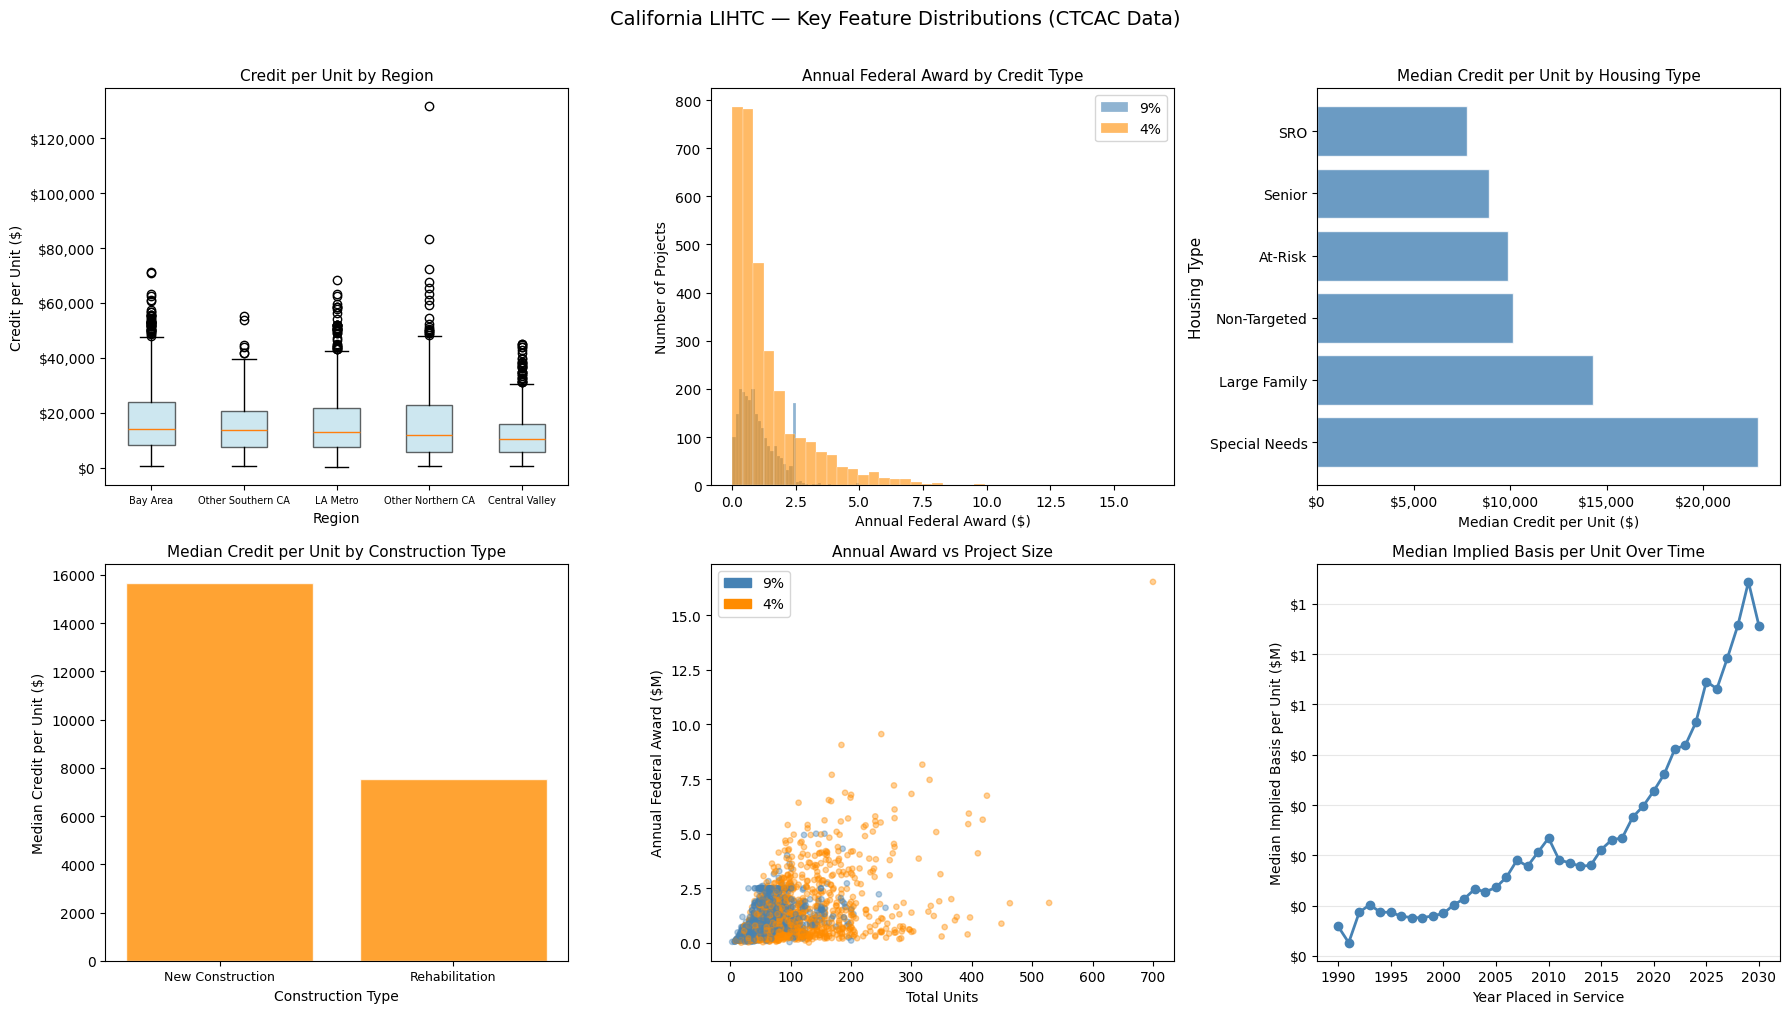

In [35]:
fig, axes = plt.subplots(2, 3, figsize =(18, 10))

#---- Credit per unit by region--------------
# boxplot of credit per unit by region, top left plot axes[0, 0] 
ax = axes[0, 0]

# Group data by region and calculate median credit per unit from highest to lowest
# Index is region name, value is median credit per unit
region_order = df.groupby('region')['credit_per_unit'].median().sort_values(ascending = False).index
#print(region_order)
# Loop through region order, compute a list of credit per unit for each region, and store in data_by_region
data_by_region = [df[df['region'] == r]['credit_per_unit'] for r in region_order]
ax.boxplot(data_by_region, labels=region_order, patch_artist=True,
           boxprops=dict(facecolor='lightblue', alpha=0.6))
ax.set_title('Credit per Unit by Region', fontsize=11)
ax.set_xlabel('Region')
ax.set_ylabel('Credit per Unit ($)')
ax.tick_params(axis='x', labelsize=7)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
#ax.grid(axis='y', alpha=0.5)

# ── Credit by credit type ──────────────────────────────────────────────────────
ax = axes[0,1]
for ct, color in zip(['9%', '4%'], ['steelblue', 'darkorange']):
    vals = df[df['credit_type'] == ct]['Annual Federal Award'] / 1_000_000
    ax.hist(vals, bins=40, alpha=0.6, label=ct, color=color, edgecolor='white', linewidth=0.3)

ax.set_title('Annual Federal Award by Credit Type', fontsize=11)
ax.set_xlabel('Annual Federal Award ($)')
ax.set_ylabel('Number of Projects')
#show 4% & 9% legend in upper right corner
ax.legend()

# ── Credit per Unit by Housing type ─────────────────────────────────────────────────────
ax = axes[0,2]
# Group data by housing type and calculate median credit per unit from highest to lowest
house_type_order = df.groupby('housing_type')['credit_per_unit'].median().sort_values(ascending=False).index
#print(house_type_order)
# reindex to ensure the order is correct for plotting, from highest to lowest per above line
house_type_medians = df.groupby('housing_type')['credit_per_unit'].median().reindex(house_type_order)
ax.barh(house_type_order, house_type_medians, color='steelblue', edgecolor='white', alpha=0.8) 
ax.set_title('Median Credit per Unit by Housing Type', fontsize=11)
ax.set_xlabel('Median Credit per Unit ($)')
ax.set_ylabel('Housing Type', fontsize=11)
ax.tick_params(axis='y', labelsize=10)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))

# ── Credit per unit by construction type ──────────────────────────────────────
ax = axes[1,0]
ct_vals = df.groupby('construction_type')['credit_per_unit'].median().sort_values(ascending=False)
ax.bar(ct_vals.index, ct_vals.values, color='darkorange', edgecolor='white', alpha=0.8)
ax.set_title('Median Credit per Unit by Construction Type', fontsize=11)
ax.set_xlabel('Construction Type')
ax.set_ylabel('Median Credit per Unit ($)')
ax.tick_params(axis='x', labelsize=9)

# ── Annual Federal Award vs Total Units (scatter) ─────────────────────────────
ax = axes[1,1]
# Scatter plot of Annual Federal Award vs Total Units, colored by credit type
# Draw at most 2000 points or len(df) to avoid overcrowding, 
# using the sample method to randomly select rows from df if necessary
sample = df.sample(n=min(2000, len(df)), random_state=42)
colors = sample['credit_type'].map({'9%': 'steelblue', '4%': 'darkorange'})
ax.scatter(sample['Total Units'], sample['Annual Federal Award'] / 1_000_000,
              alpha=0.4, color=colors, s=15)
ax.set_title('Annual Award vs Project Size', fontsize=11)
ax.set_xlabel('Total Units')
ax.set_ylabel('Annual Federal Award ($M)')
from matplotlib.patches import Patch
ax.legend(handles=[Patch(color='steelblue', label='9%'), Patch(color='darkorange', label='4%')])

# ── Implied basis per unit over time ──────────────────────────────────────────
ax = axes[1, 2]
basis_trend = df.groupby('pis_year')['implied_basis_per_unit'].median()
ax.plot(basis_trend.index, basis_trend.values/1_000_000, marker='o', color='steelblue', linewidth=2)
ax.set_title('Median Implied Basis per Unit Over Time', fontsize=11)
ax.set_xlabel('Year Placed in Service')
ax.set_ylabel('Median Implied Basis per Unit ($M)')
ax.grid(axis='y', alpha=0.3)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))


plt.suptitle('California LIHTC — Key Feature Distributions (CTCAC Data)', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

### 11. Correlation with Target Variable
Check which numeric features have the strongest correlation/relationship with Annual Federal Award

In [36]:
#Check df info after cleaning step and check column dtype
print(f'Total number of rows after cleaning: {len(df):,}')
print()
df.info(verbose=True, show_counts=True)

Total number of rows after cleaning: 5,496

<class 'pandas.DataFrame'>
Index: 5496 entries, 0 to 6102
Data columns (total 80 columns):
 #   Column                          Non-Null Count  Dtype         
---  ------                          --------------  -----         
 0   Application Number              5496 non-null   str           
 1   Type of tax credit funding      5496 non-null   object        
 2   Construction Type               5496 non-null   str           
 3   Developer                       5074 non-null   str           
 4   Housing Type                    5493 non-null   str           
 5   Project Name                    5496 non-null   str           
 6   Project Address                 5496 non-null   str           
 7   Project City                    5496 non-null   str           
 8   Project Zip Code                5496 non-null   object        
 9   Project Phone Number            4255 non-null   object        
 10  Project County                  5496 non-nul

<Axes: >

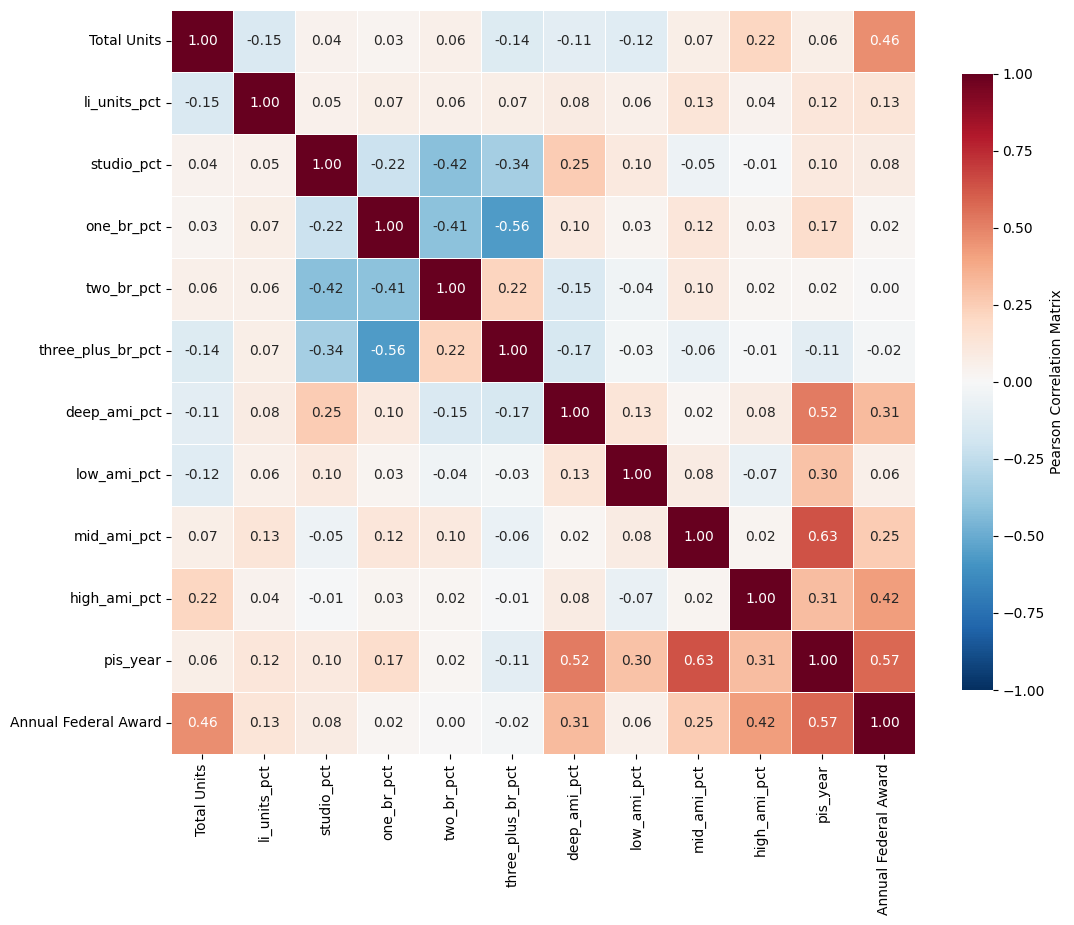

In [37]:
numeric_features = ['Total Units', 'li_units_pct',
    'studio_pct', 'one_br_pct', 'two_br_pct', 'three_plus_br_pct',
    'deep_ami_pct', 'low_ami_pct', 'mid_ami_pct', 'high_ami_pct',
    'pis_year']
target = 'Annual Federal Award'

# Find correlation matrix bt columns (for numeric features and target variable)
corr_matrix = df[numeric_features + [target]].corr()

fig, ax = plt.subplots(figsize = (12, 10))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            vmin=-1, vmax=1, square=True, linewidths=0.5, 
            cbar_kws={'shrink': 0.8, 'label': 'Pearson Correlation Matrix'}, ax=ax)

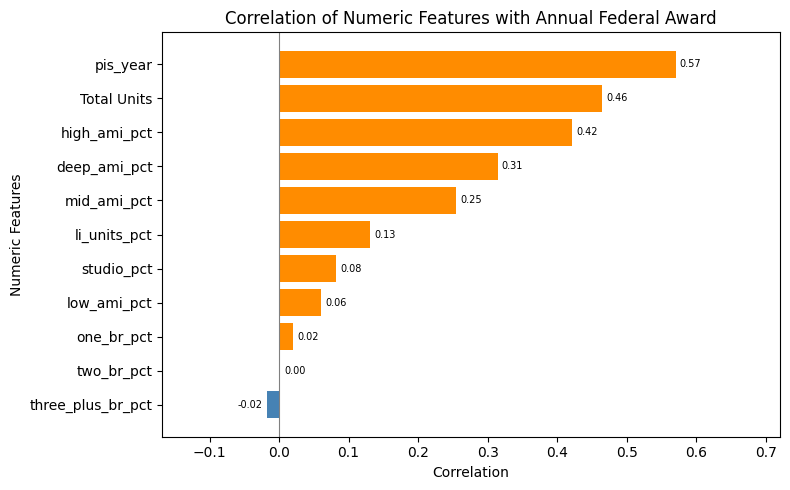

In [38]:
# Sorted Correlation with Target variable
target_corr = corr_matrix[target].drop(target).sort_values(ascending=True)
#target_corr

fig, ax = plt.subplots(figsize=(8,5))
colors = ['darkorange' if val>0 else 'steelblue' for val in target_corr]
bars = ax.barh(target_corr.index, target_corr.values, color=colors)
ax.bar_label(bars, fmt='%.2f', padding=3,fontsize=7 )

ax.set_title('Correlation of Numeric Features with Annual Federal Award', fontsize=12)
ax.set_xlabel('Correlation', fontsize=10)
ax.set_ylabel('Numeric Features', fontsize=10)

#add vertical line at x=0 to separate positive and negative correlations
ax.axvline(0, color='grey', linewidth=0.8) 
#add space on x axis limits to prevent labels from being cut off, add 0.15 on both sides
ax.set_xlim(target_corr.min() - 0.15, target_corr.max() + 0.15)

plt.tight_layout()
plt.show()

### 12. Final Clean Dataset Summary

In [39]:
print('=== Final Dataset Summary ===')
print(f'Total Records: {len(df):,}')
print(f'Place In Service Year Range: {df["pis_year"].min()} - {df["pis_year"].max()}')
print(f'Number of Counties Covered: {df["Project County"].nunique()}')
print()
print('Credit type:')
print(df["credit_type"].value_counts().to_string())
print()
print('Housing type:')
print(df['housing_type'].value_counts().to_string())
print()
print('Construction type:')
print(df['construction_type'].value_counts().to_string())
print()
print('Annual Federal Award:')
print(df['Annual Federal Award'].describe().apply('${:,.0f}'.format))
print()
print('Train/test split plan:')

n_total = df[df['pis_year'].between(2000, 2025)].shape[0]
n_train = df[df['pis_year'].between(2000, 2021)].shape[0]
n_test = df[df['pis_year'].between(2022, 2025)].shape[0]
print(f'Total Train Test Projects (2000-2025):  {n_total:,} (100%)')
print(f'Training Projects (2000-2021):          {n_train:,} ({n_train/n_total*100:.2f}%)')
print(f'Testing Projects (2022-2025):           {n_test:,} ({n_test/n_total*100:.2f}%)')


=== Final Dataset Summary ===
Total Records: 5,496
Place In Service Year Range: 1990.0 - 2030.0
Number of Counties Covered: 60

Credit type:
credit_type
4%    3113
9%    2383

Housing type:
housing_type
Large Family     2545
Senior           1043
Non-Targeted      961
Special Needs     586
At-Risk           215
SRO               146

Construction type:
construction_type
New Construction    3710
Rehabilitation      1786

Annual Federal Award:
count         $5,496
mean      $1,234,540
std       $1,211,457
min          $11,119
25%         $445,466
50%         $855,592
75%       $1,601,731
max      $16,529,220
Name: Annual Federal Award, dtype: str

Train/test split plan:
Total Train Test Projects (2000-2025):  4,387 (100%)
Training Projects (2000-2021):          3,536 (80.60%)
Testing Projects (2022-2025):           851 (19.40%)


In [40]:
# ── Select and rename the final columns we need ────────────────────────────────
final_cols = {
    'Application Number':    'app_number',
    'Project Name':          'project_name',
    'Project County':        'county',
    'Project City':          'city',
    'Census Tract':          'census_tract',
    'Developer':             'developer',
    'pis_year':              'pis_year',
    'credit_type':           'credit_type',
    'construction_type':     'construction_type',
    'housing_type':          'housing_type',
    'region':                'region',
    'Total Units':           'total_units',
    'Low Income Units':      'li_units',
    'li_units_pct':          'li_units_pct',
    'studio_pct':            'studio_pct',
    'one_br_pct':            'one_br_pct',
    'two_br_pct':            'two_br_pct',
    'three_plus_br_pct':     'three_plus_br_pct',
    'deep_ami_pct':          'deep_ami_pct',
    'low_ami_pct':           'low_ami_pct',
    'mid_ami_pct':           'mid_ami_pct',
    'high_ami_pct':          'high_ami_pct',
    'credit_per_unit':       'credit_per_unit',
    'implied_eligible_basis':'implied_eligible_basis',
    'implied_basis_per_unit':'implied_basis_per_unit',
    'Total State Award':     'total_state_award',
    'Annual Federal Award':  'annual_federal_award'}

df_clean = df[final_cols.keys()].rename(columns=final_cols)
print(f'Clean Dataset: {df_clean.shape[0]:,} rows X {df_clean.shape[1]:,} columns')
df_clean.head(5)

Clean Dataset: 5,496 rows X 27 columns


,app_number,project_name,county,city,census_tract,developer,pis_year,credit_type,construction_type,housing_type,region,total_units,li_units,li_units_pct,studio_pct,one_br_pct,two_br_pct,three_plus_br_pct,deep_ami_pct,low_ami_pct,mid_ami_pct,high_ami_pct,credit_per_unit,implied_eligible_basis,implied_basis_per_unit,total_state_award,annual_federal_award
0,CA-1989-279,Tres Palmas Village 90-001,Imperial,Brawley,NaN,Opportunity Housing,"1,990",9%,New Construction,Large Family,Other Southern CA,55,55,1,0,0,0,0,0,0,0,0,"1,784","1,090,456","19,826",NaN,"98,141"
1,CA-1990-011,Villa Los Robles,Los Angeles,Pasadena,4619.01,"CKMP, Inc","1,992",9%,New Construction,Large Family,LA Metro,8,8,1,0,0,0,0,0,0,0,0,"9,169","814,989","101,874","357,576","73,349"
2,CA-1990-012,Casa Loma Apartments,Los Angeles,Los Angeles,2091.04,New Economics for Women,"1,993",9%,New Construction,Large Family,LA Metro,110,110,1,0,0,0,0,0,0,0,0,"13,786","16,849,944","153,181",NaN,"1,516,495"
3,CA-1990-014,San Pedro Gardens,Santa Clara,Morgan Hill,5123.10,"S.P.G. Housing, Inc.","1,992",9%,New Construction,Large Family,Bay Area,20,17,1,0,0,0,0,0,0,0,0,"13,877","3,627,974","181,399",NaN,"277,540"
4,CA-1990-018,Yucaipa Terrace,San Bernardino,Yucaipa,87.04,"Housing Partners, Inc.","1,991",9%,New Construction,Senior,LA Metro,51,51,1,0,0,0,0,0,0,0,0,"5,674","3,215,189","63,043",NaN,"289,367"


In [41]:
# ── Save to CSV for now (parquet in next notebook when we add FRED/Census/FMR) ──
# Create processed folder if it doesn't exist
os.makedirs('processed', exist_ok=True)
# Save df_clean to processed foder as ctcac_clean.csv without the index column
df_clean.to_csv('processed/ctcac_clean.csv', index=False)
print('Saved: processed/ctcac_clean.csv')
print(f'Rows: {len(df_clean):,}   Columns: {df_clean.shape[1]}')

Saved: processed/ctcac_clean.csv
Rows: 5,496   Columns: 27


---
## Next Steps

1. **Next notebook** (`02_enrich_data.ipynb`): Join FRED PPI by year, HUD FMR by county, Census ACS by county
2. **After enrichment**: Save final `lihtc_ca_clean.parquet`
3. **Then**: `03_feature_engineering.ipynb` — build sklearn ColumnTransformer pipeline
4. **Then**: `04_modeling.ipynb` — train Ridge → Random Forest → XGBoost → LightGBM quantile → Stacking Regressor

---
*End of data exploration notebook*